In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [38]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 1 (Jun 2022 - May 2023)\Load_hourly\48190963_Loads_hourly.csv"
df = pd.read_csv(path)

In [39]:
df.head()

,Timestamp,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heat pump electric,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,SHW,Solar rapid shutdown,Control,NET,IN,OUT
0,2022-06-01 00:00:00-04:00,0.190117,0.002001,0.003973,0.0,0.001130,0.030370,0.109032,0.065145,0,...,0.002586,-0.050127,-0.048380,0.003126,0.001044,0.003929,0.200769,1.422260,1.422260,0.0
1,2022-06-01 01:00:00-04:00,0.198712,0.002010,0.003989,0.0,0.001148,0.030482,0.109224,0.065428,0,...,0.002585,-0.049362,-0.050536,0.003116,0.001162,0.004033,0.201539,1.438863,1.438863,0.0
2,2022-06-01 02:00:00-04:00,0.163461,0.001990,0.003988,0.0,0.001133,0.030422,0.109083,0.065517,0,...,0.002590,-0.048622,-0.047862,0.003119,0.001154,0.004018,0.203426,1.401933,1.401933,0.0
3,2022-06-01 03:00:00-04:00,0.173353,0.002003,0.003970,0.0,0.001137,0.030350,0.108715,0.064750,0,...,0.002576,-0.048963,-0.050321,0.003120,0.000599,0.003993,0.199362,1.410452,1.410452,0.0
4,2022-06-01 04:00:00-04:00,0.197125,0.001997,0.003942,0.0,0.001126,0.030064,0.108166,0.064047,0,...,0.002554,-0.048785,-0.049283,0.003112,0.000231,0.003896,0.198860,1.426215,1.426215,0.0


In [40]:
df.describe()

,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heat pump electric,Heating,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,SHW,Solar rapid shutdown,Control,NET,IN,OUT
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.0,8760.000000,...,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,0.105188,0.033311,0.003984,0.033277,0.001110,0.043071,0.064248,0.064461,0.0,0.306174,...,0.008618,0.861082,0.752543,0.003108,0.004548,0.004031,0.154528,-0.078284,1.065403,-1.143643
std,0.047538,0.071705,0.000125,0.094626,0.000036,0.009515,0.052435,0.001033,0.0,0.379250,...,0.029136,1.451156,1.330520,0.000009,0.012399,0.000108,0.025816,2.804568,0.815668,2.192510
min,0.030904,0.000000,0.003564,-0.000011,0.000959,0.000000,0.000000,0.059401,0.0,0.000000,...,0.001003,-0.106541,-0.095593,0.003067,0.000000,0.003653,0.125876,-10.038336,0.000000,-10.038336
25%,0.081427,0.000000,0.003889,0.000000,0.001091,0.030088,0.000000,0.063905,0.0,0.000000,...,0.002497,-0.048601,-0.046635,0.003102,0.000000,0.003955,0.132340,-1.129140,0.041972,-1.214757
50%,0.094266,0.001907,0.003996,0.000000,0.001111,0.047897,0.104450,0.064573,0.0,0.032095,...,0.002542,0.000000,0.000000,0.003108,0.000113,0.004028,0.146931,1.239218,1.239913,0.000000
75%,0.118680,0.001993,0.004080,0.000000,0.001134,0.048985,0.107158,0.065114,0.0,0.666685,...,0.002593,1.388279,1.184871,0.003114,0.000975,0.004102,0.164226,1.769007,1.769871,0.000000
max,0.952750,0.202686,0.004299,1.600796,0.001229,0.092243,0.122138,0.074380,0.0,2.082851,...,0.283961,8.081354,5.711190,0.003146,0.054776,0.004666,0.215571,3.440907,3.440907,0.000000


In [41]:
df.isna().sum()

Timestamp               0
Plug_Basement           0
Cooling                 0
Exhaust fan             0
EHW                     0
Sumppump                0
Emergency light load    0
EL                      0
Fire alarm              0
Heat pump electric      0
Heating                 0
IT                      0
Lighting                0
Plug1                   0
Plug2                   0
Plug3                   0
PV_meter1_load (kW)     0
PV_meter2_load (kW)     0
Battery cabinet         0
SHW                     0
Solar rapid shutdown    0
Control                 0
NET                     0
IN                      0
OUT                     0
dtype: int64

In [42]:
num = df.select_dtypes(include='number')
zero_counts = (num == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(2)
zeros_summary = pd.concat([zero_counts.rename('zero_count'), zero_pct.rename('zero_pct')], axis=1).sort_values('zero_count', ascending=False)
zeros_summary

,zero_count,zero_pct
Heat pump electric,8760,100.00
EHW,7597,86.72
OUT,5416,61.83
SHW,4181,47.73
Cooling,4043,46.15
Heating,3640,41.55
EL,3452,39.41
IN,1767,20.17
PV_meter2_load (kW),1731,19.76
PV_meter1_load (kW),935,10.67


In [43]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_19028\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [44]:
df= df.drop(columns=['Heat pump electric'])
sorted(df.columns)

['Battery cabinet',
 'Control',
 'Cooling',
 'EHW',
 'EL',
 'Emergency light load',
 'Exhaust fan',
 'Fire alarm',
 'Heating',
 'IN',
 'IT',
 'Lighting',
 'NET',
 'OUT',
 'PV_meter1_load (kW)',
 'PV_meter2_load (kW)',
 'Plug1',
 'Plug2',
 'Plug3',
 'Plug_Basement',
 'SHW',
 'Solar rapid shutdown',
 'Sumppump']

In [45]:
df.corr()

,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heating,IT,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,SHW,Solar rapid shutdown,Control,NET,IN,OUT
Plug_Basement,1.000000,-0.001366,-0.038090,0.114549,-0.139828,0.122138,-0.094970,-0.066417,0.193094,0.122820,...,-0.015239,0.099736,0.060033,0.035640,0.115367,0.035138,0.062010,-0.076355,-0.022108,-0.087006
Cooling,-0.001366,1.000000,-0.584123,-0.091421,-0.492760,-0.680577,0.354435,-0.582573,-0.374777,0.190504,...,0.036212,0.097601,0.128156,-0.372369,0.142059,0.182923,0.793286,-0.162736,-0.157897,-0.149433
Exhaust fan,-0.038090,-0.584123,1.000000,0.013462,0.736958,0.618468,-0.258463,0.670201,0.343489,-0.198071,...,-0.196327,-0.173897,-0.167434,0.335153,-0.069318,-0.195059,-0.480551,0.215165,0.211240,0.198185
EHW,0.114549,-0.091421,0.013462,1.000000,0.031488,0.114358,-0.092212,0.087154,0.068041,0.004360,...,-0.004312,0.133664,0.091987,0.062437,0.056941,0.020752,-0.050772,-0.063842,-0.063495,-0.076150
Sumppump,-0.139828,-0.492760,0.736958,0.031488,1.000000,0.425584,-0.123492,0.851407,0.017106,-0.298860,...,-0.151532,-0.033826,-0.061116,0.301592,-0.073955,-0.118359,-0.474472,0.059946,0.024436,0.070921
Emergency light load,0.122138,-0.680577,0.618468,0.114358,0.425584,1.000000,-0.469538,0.553343,0.506263,-0.189391,...,-0.181568,-0.159972,-0.205312,0.384174,-0.161553,-0.216111,-0.563669,0.252930,0.276483,0.221799
EL,-0.094970,0.354435,-0.258463,-0.092212,-0.123492,-0.469538,1.000000,-0.329445,-0.491104,-0.007083,...,0.104439,0.084012,0.116230,-0.275930,0.132739,0.201284,0.198006,-0.151758,-0.208669,-0.115438
Fire alarm,-0.066417,-0.582573,0.670201,0.087154,0.851407,0.553343,-0.329445,1.000000,0.203116,-0.322636,...,-0.190629,-0.094178,-0.123239,0.356922,-0.183298,-0.234256,-0.506804,0.141402,0.153790,0.122905
Heating,0.193094,-0.374777,0.343489,0.068041,0.017106,0.506263,-0.491104,0.203116,1.000000,0.072942,...,-0.077030,-0.204587,-0.280387,0.388940,-0.103166,-0.284557,-0.042413,0.375148,0.518364,0.277480
IT,0.122820,0.190504,-0.198071,0.004360,-0.298860,-0.189391,-0.007083,-0.322636,0.072942,1.000000,...,0.104460,0.163009,0.202048,-0.094423,0.223537,0.127106,0.245444,-0.178146,-0.096614,-0.190347


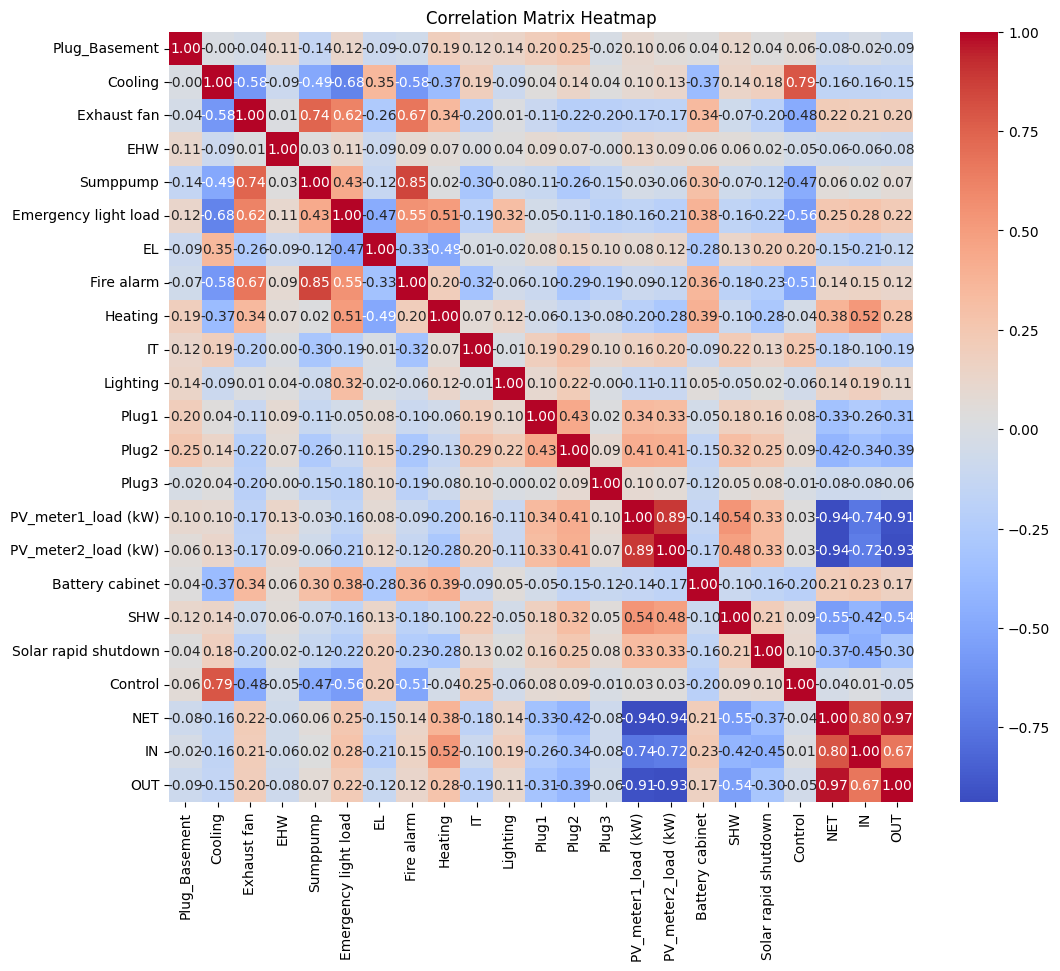

In [46]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

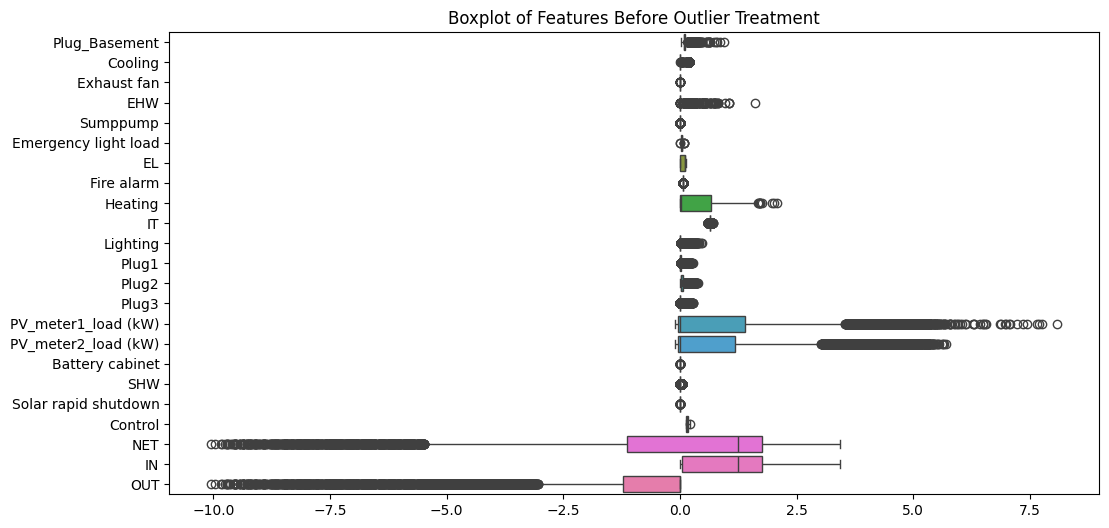

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, orient = 'h')
plt.title('Boxplot of Features Before Outlier Treatment')
plt.show()

In [48]:
# def treat_outliers_iqr(df):
#     df_clean = df.copy()
#     for col in df_clean.columns:
#         Q1 = df_clean[col].quantile(0.25)
#         Q3 = df_clean[col].quantile(0.75)
#         IQR = Q3 - Q1


#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
#     return df_clean
# df = treat_outliers_iqr(df)
# df.shape

In [49]:
# plt.figure(figsize=(12,6))
# sns.boxplot(data=df, orient = 'h')
# plt.title('Boxplot of Features After Outlier Treatment')
# plt.show()